In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import xarray as xr
from klepto.archives import file_archive
from diagnostics_pkg import operators_layered as ol
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import numpy.ma as ma
import qgutils as qg
import matplotlib as mpl
from skimage import measure
from scipy import interpolate

/home/lennard/miniconda3/envs/DA/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/lennard/miniconda3/envs/DA/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


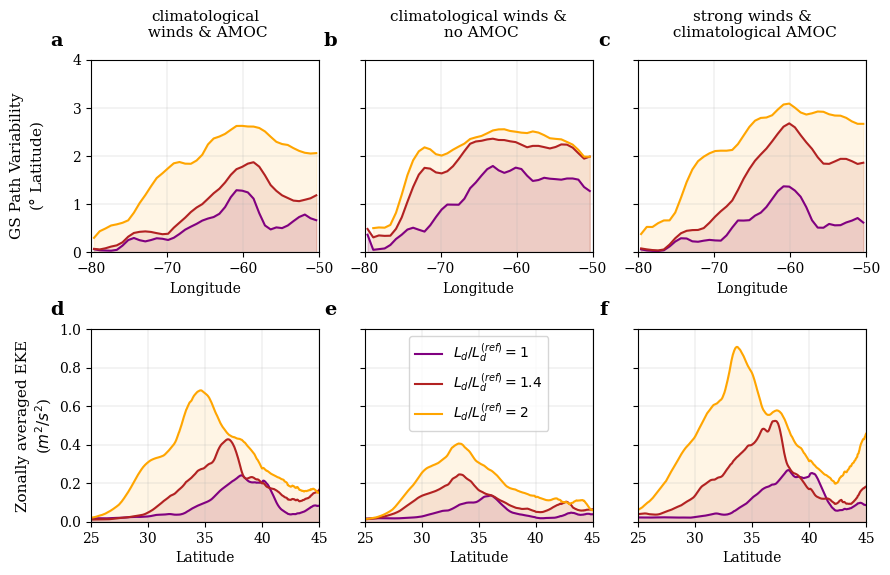

In [2]:
savepaths = ["../Spaghetti_plot_and_variability/data/", "../Spaghetti_plot_and_variability_no_AMOC/data/", "../Spaghetti_plot_and_variability_strong_winds/data/"] 

drho_facs = [1,2,4]
letters = ["a", "d", "b", "e", "c", "f"]

plt.rcParams['font.family'] = 'serif'

fig = plt.figure(figsize=(10, 6))
grid = plt.GridSpec(2, 3, hspace=0.4, wspace=0.2)

ylabels = ["climatological\n winds & AMOC","climatological winds &\n no AMOC", "strong winds &\n climatological AMOC"]
kk = 0

for ii in range(3): # loop through three boundary conditions: climatological, no AMOC, and strong winds.
    
    axes_l = fig.add_subplot(grid[0,ii])
    axes_r = fig.add_subplot(grid[1,ii])

    savepath = savepaths[ii]
    N_fin = 3000 # total number of points per path line
    
    # calculate standart deviation in bins.
    
    min_lon = - 80
    max_lon = -50
    N_bins = 40
    dlon = (max_lon - min_lon)/N_bins
    
    bin_lims = np.linspace(min_lon, max_lon, N_bins + 1)
    bin_sum = np.zeros(N_bins) # store the sum of the mean latitudes in each section
    bin_sum_sq = np.zeros(N_bins) # store the sum of the square of all mean latitudes in each section
    bin_n = np.zeros(N_bins) # store the number of sections in each bin
    lon = (bin_lims[:-1]+bin_lims[1:])/2
    
    nn_bins = np.zeros(N_bins)
    
    stds = np.zeros([N_bins, 3])
    i = 0
    
    for drho_fac in drho_facs:
        
        # add spaghettis
        conts_load = np.load(savepath + "conts_" + str(drho_fac) + "drho.npz", allow_pickle=False)
        N_cont = len(conts_load) - 1
        
        for j in range(0, N_cont): # loop through path lines
            cont = conts_load[str(j)]
            xs = cont[0,:N_fin]
            ys = cont[1,:N_fin]
            for k in range(0,N_fin): # find starting point
                x = xs[k]
                if min_lon < x: # loop through segments
                    k_i = k
                    break
            n_bin_old = 0
            for k in range(k_i, len(xs)):
                x = xs[k]
                if int((x - min_lon)/dlon) != n_bin_old:
                    if 0 <= n_bin_old < N_bins:
                        nn_bins[n_bin_old] += 1
                        bin_sum[n_bin_old] += np.mean(ys[k_i:k])
                        bin_sum_sq[n_bin_old] += np.mean(ys[k_i:k])**2
                        k_i = k
                    n_bin_old = int((x - min_lon)/dlon)
    
        stds[:,i] = np.sqrt(bin_sum_sq/nn_bins - (bin_sum/nn_bins)**2)
        i += 1
        
    lat_min = 25
    lat_max = 50
    lon_min = -80
    lon_max = -40
    
    if ii == 0:
        
        i = 0
    
        lat = xr.open_dataset(savepath + "v_std_2048_1drho.nc", decode_times=False)["u.y"].y
        eke_profiles = np.zeros([len(lat),3])
        
        for drho_fac in drho_facs:
                    
            # u_std
            ds_std = xr.open_dataset(savepath + "u_std_2048_" + str(drho_fac) + "drho.nc", decode_times=False)
            u_std = ds_std["u.x"].sel(x=slice(lon_min, lon_max))
            lat_mod = u_std.y
            lon_mod = u_std.x
            
            # v_std
            ds_std = xr.open_dataset(savepath + "v_std_2048_" + str(drho_fac) + "drho.nc", decode_times=False)
            v_std = ds_std["u.y"].sel(x=slice(lon_min, lon_max))
            
            eke = u_std[-1,:,:]**2 + v_std[-1,:,:]**2
            lat = eke.y
            
            # mask
            ds_topo = xr.open_dataset(savepath + "topo.nc")
            topo = ds_topo["zb"][0,0,:,:]
            mask = topo > 0
            mask = mask.sel(x=slice(lon_min, lon_max))
            eke_mask = ma.masked_array(eke, mask=mask)
            eke_profiles[:,i] =  np.nanmean(eke_mask, axis = 1)
            i += 1
    else: 
                
        lat = xr.open_dataset(savepath + "U_std_2048_" + str(drho_fac) + "drho.nc", decode_times=False)["__xarray_dataarray_variable__"].y
        eke_profiles = np.zeros([len(lat),3])
        
        i = 0
        
        for drho_fac in drho_facs:
            
            # eke
            ds_std = xr.open_dataset(savepath + "U_std_2048_" + str(drho_fac) + "drho.nc", decode_times=False)
            eke = ds_std["__xarray_dataarray_variable__"].sel(x=slice(lon_min, lon_max))[-1,:,:]**2
            lat_mod = eke.y
            lon_mod = eke.x
            
            # mask
            ds_topo = xr.open_dataset(savepath + "topo.nc")
            topo = ds_topo["zb"][0,0,:,:]
            mask = topo > 0
            mask = mask.sel(x=slice(lon_min, lon_max))
            eke_mask = ma.masked_array(eke, mask=mask)
            eke_profiles[:,i] =  np.nanmean(eke_mask, axis = 1)
            i += 1
    
    
    # add grid
    axes_l.grid(zorder = 1, linewidth = 0.2)
    
    # set lateral and longitudinal extend
    axes_l.set_xlim([-80, -50])
    axes_l.set_ylim([0, 4])
    
    axes_l.text(-0.15, 1.1, letters[kk], weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes_l.transAxes, size = 14)
    kk += 1
    
    axes_l.set_xlabel("Longitude")
    axes_r.set_xlabel("Latitude")
    axes_r.set_xticks(np.arange(25,45.1,5))
    
    # axes_l.set_ylabel("GS Path Variability\n" + r"(standard deviation, $°$ Latitude)")
    # axes_l.yaxis.set_label_coords(-0.125,0.475)
    
    axes_l.set_title(ylabels[ii], size = 11, y = 1.075)

    # add grid
    axes_r.grid(zorder = 1, linewidth = 0.2)
    
    # set lateral and longitudinal extend
    axes_r.set_xlim([25, 45])
    axes_r.set_ylim([0, 1])
    
    axes_r.text(-0.15, 1.1, letters[kk], weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes_r.transAxes, size = 14)
    kk += 1
    if ii == 0:
        axes_r.set_ylabel("Zonally averaged EKE\n" + r"($m^2/s^2$)", size = 11)
        axes_l.set_ylabel("GS Path Variability\n" + r"($°$ Latitude)", size = 11)
        axes_l.yaxis.set_label_coords(-0.2,0.45)
    else: 
        axes_l.set_yticklabels([])
        axes_r.set_yticklabels([])
    #axes_r.yaxis.set_label_coords(-0.125,0.45)
    cs = ["purple", "firebrick", "orange"]
    labels = ['$L_d/L_d^{(ref)} = 1$', '$L_d/L_d^{(ref)} = 1.4$', '$L_d/L_d^{(ref)} = 2$']
    
    Rd_labels = ["1", "1.4", "2"]
    
    R0 = 39066.430787677964
    
    for i, drho_fac in enumerate(drho_facs):
    
        axes_l.fill_between(lon, stds[:,i], color = cs[i], alpha = 0.1)
        axes_l.plot(lon, stds[:,i], color = cs[i], label = labels[i])
    
        axes_r.fill_between(lat, eke_profiles[:,i], color = cs[i], alpha = 0.1)
        axes_r.plot(lat, eke_profiles[:,i], color = cs[i], label = labels[i])

    if ii == 1:
        axes_r.legend(loc = "upper center")
        
plt.savefig('variability_all_runs.png', dpi = 200, bbox_inches='tight', format = 'png')